# Phase 3 & 4 — Model Building & Training
Custom CNN + Transfer Learning (TensorFlow/Keras)

In [1]:
import os, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Config ──────────────────────────────────────────────
DATASET_ROOT = Path('classification_dataset')   # <-- update if needed
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 30          # EarlyStopping will cut this short
SEED         = 42
NUM_CLASSES  = 1           # binary → sigmoid output

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('TF version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TF version: 2.17.0
GPU available: False


## 3.1 — Data Generators

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    DATASET_ROOT / 'TRAIN',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

valid_gen = val_test_datagen.flow_from_directory(
    DATASET_ROOT / 'VALID',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    DATASET_ROOT / 'TEST',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Save class indices for Streamlit
class_indices = train_gen.class_indices
print('Class indices:', class_indices)
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

# Class weights to handle mild imbalance
total = sum(train_gen.samples for _ in [1])
n_bird  = train_gen.classes.tolist().count(class_indices.get('bird', 0))
n_drone = train_gen.classes.tolist().count(class_indices.get('drone', 1))
w_bird  = total / (2 * n_bird)
w_drone = total / (2 * n_drone)
class_weight = {class_indices.get('bird', 0): w_bird,
                class_indices.get('drone', 1): w_drone}
print('Class weights:', class_weight)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices: {'bird': 0, 'drone': 1}
Class weights: {0: 0.9413012729844413, 1: 1.0665064102564104}


## 3.2 — Common Callbacks

In [9]:
def make_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f'{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

## 3.3 — Model A: Custom CNN

In [10]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    inp = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='CustomCNN')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,321 (2.55 MB)

 Trainable params: 666,401 (2.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 4.1 — Train Custom CNN

In [11]:
print('Training Custom CNN...')
cnn_history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    class_weight=class_weight,
    callbacks=make_callbacks('custom_cnn'),
    verbose=1
)
print('Custom CNN training complete!')

Training Custom CNN...
Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6038 - loss: 0.9122 - precision: 0.5686 - recall: 0.6854
Epoch 1: val_accuracy improved from -inf to 0.50905, saving model to custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 331s 4s/step - accuracy: 0.6042 - loss: 0.9108 - precision: 0.5690 - recall: 0.6851 - val_accuracy: 0.5090 - val_loss: 0.8449 - val_precision: 0.5090 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6744 - loss: 0.7126 - precision: 0.6433 - recall: 0.6442
Epoch 2: val_accuracy improved from 0.50905 to 0.67873, saving model to custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.6743 - loss: 0.7126 - precision: 0.6433 - recall: 0.6442 - val_accuracy: 0.6787 - val_loss: 0.6627 - val_precision: 0.7219 - val_recall: 0.6000 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6734 - loss: 0.6744 - precision: 0.6555 - rec

## 3.4 — Model B: Transfer Learning (EfficientNetB0)

In [12]:
def build_transfer_model(base_name='EfficientNetB0', input_shape=(224, 224, 3)):
    # Load base model
    base_classes = {
        'EfficientNetB0': keras.applications.EfficientNetB0,
        'MobileNetV2':    keras.applications.MobileNetV2,
        'ResNet50':       keras.applications.ResNet50,
    }
    BaseModel = base_classes[base_name]
    base = BaseModel(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    # Phase 1: freeze base, train head only
    base.trainable = False

    inp = keras.Input(shape=input_shape)
    # EfficientNet includes its own preprocessing; others need explicit rescale
    if base_name == 'EfficientNetB0':
        x = base(inp, training=False)
    else:
        x = base(inp, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name=f'TL_{base_name}')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model, base

tl_model, base_model = build_transfer_model('EfficientNetB0')
tl_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "TL_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,395,044 (16.77 MB)

 Trainable params: 344,961 (1.32 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 4.2 — Train Transfer Model (Phase 1: frozen base)

In [13]:
print('Transfer Learning — Phase 1: training head only...')
tl_history1 = tl_model.fit(
    train_gen,
    epochs=15,
    validation_data=valid_gen,
    class_weight=class_weight,
    callbacks=make_callbacks('tl_phase1'),
    verbose=1
)

Transfer Learning — Phase 1: training head only...
Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.4991 - loss: 0.7742 - precision: 0.4664 - recall: 0.5214
Epoch 1: val_accuracy improved from -inf to 0.49095, saving model to tl_phase1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 93s 975ms/step - accuracy: 0.4992 - loss: 0.7741 - precision: 0.4665 - recall: 0.5214 - val_accuracy: 0.4910 - val_loss: 0.7244 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.4930 - loss: 0.7864 - precision: 0.4664 - recall: 0.5422
Epoch 2: val_accuracy improved from 0.49095 to 0.50905, saving model to tl_phase1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 81s 939ms/step - accuracy: 0.4930 - loss: 0.7863 - precision: 0.4665 - recall: 0.5422 - val_accuracy: 0.5090 - val_loss: 0.7235 - val_precision: 0.5090 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 

## 4.3 — Fine-tune (Phase 2: unfreeze top layers)

In [14]:
# Unfreeze top 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower LR for fine-tuning
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print('Transfer Learning — Phase 2: fine-tuning top 30 layers...')
tl_history2 = tl_model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    class_weight=class_weight,
    callbacks=make_callbacks('tl_finetuned'),
    verbose=1
)
print('Transfer learning training complete!')

Transfer Learning — Phase 2: fine-tuning top 30 layers...
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.4962 - loss: 0.9108 - precision: 0.4619 - recall: 0.5932
Epoch 1: val_accuracy improved from -inf to 0.50905, saving model to tl_finetuned_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.4961 - loss: 0.9108 - precision: 0.4619 - recall: 0.5929 - val_accuracy: 0.5090 - val_loss: 1.2249 - val_precision: 0.5090 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.5001 - loss: 0.8904 - precision: 0.4792 - recall: 0.5455
Epoch 2: val_accuracy did not improve from 0.50905
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5001 - loss: 0.8903 - precision: 0.4792 - recall: 0.5455 - val_accuracy: 0.5090 - val_loss: 1.2660 - val_precision: 0.5090 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.5068 - loss: 0.8889 - precision: 0.

## 4.4 — Plot Training Curves

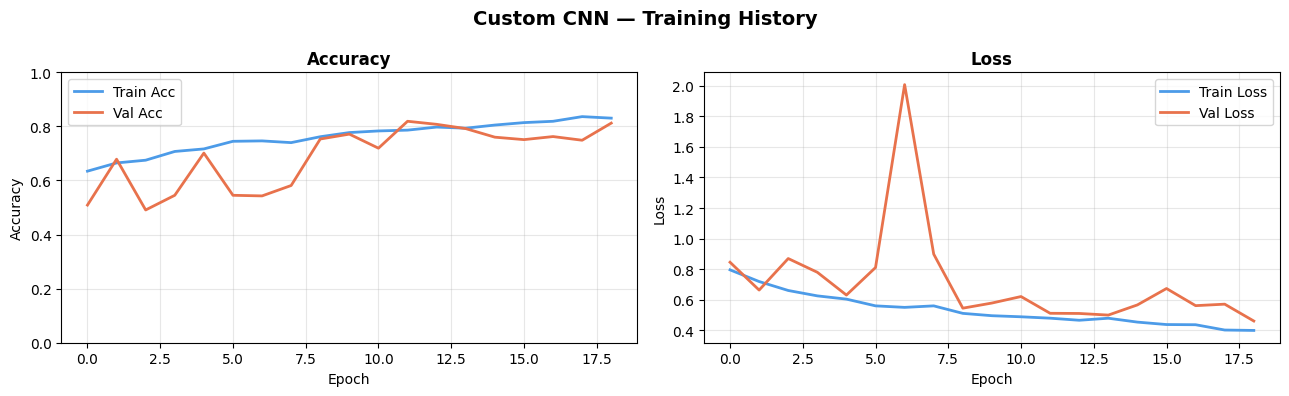

Saved: cnn_history.png


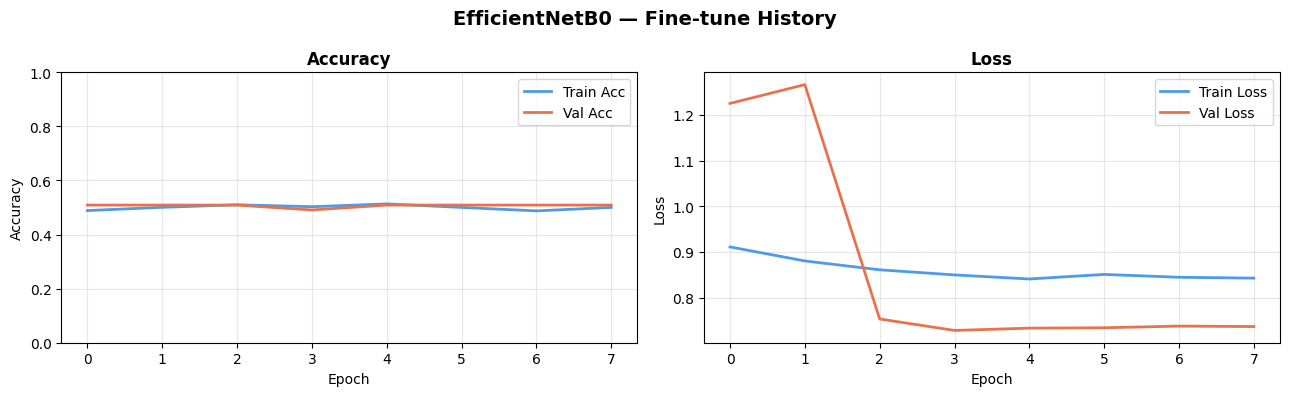

Saved: tl_history.png


In [15]:
def plot_history(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    h = history.history

    # Accuracy
    axes[0].plot(h['accuracy'],     label='Train Acc',  color='#4C9BE8', linewidth=2)
    axes[0].plot(h['val_accuracy'], label='Val Acc',    color='#E8724C', linewidth=2)
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Loss
    axes[1].plot(h['loss'],     label='Train Loss', color='#4C9BE8', linewidth=2)
    axes[1].plot(h['val_loss'], label='Val Loss',   color='#E8724C', linewidth=2)
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_history(cnn_history,  'Custom CNN — Training History',       'cnn_history.png')
plot_history(tl_history2,  'EfficientNetB0 — Fine-tune History',  'tl_history.png')

## 4.5 — Save Both Models

In [17]:
cnn_model.save('custom_cnn_final.h5')
tl_model.save('tl_efficientnet_final.h5')
print('Models saved!')
print('  custom_cnn_final.h5')
print('  tl_efficientnet_final.h5')

Models saved!
  custom_cnn_final.h5
  tl_efficientnet_final.h5
